# 🚗 Toronto Traffic Collision Severity Prediction
## Notebook 3 of 5 — Exploratory Data Analysis (EDA)

**Author:** Nishi Bhavesh Patel | Student ID: 501356244

---
### What this notebook does:
- Loads the cleaned dataset from Notebook 2
- Produces 8 key visualizations:
  1. Severity class distribution
  2. Collisions by hour of day
  3. Collisions by month
  4. Collisions by day of week
  5. Weather vs severity
  6. Correlation heatmap
  7. Top neighbourhoods by fatal collisions
  8. Temperature distribution by severity
- All plots saved as PNG files

### Input file: `collisions_cleaned.csv`

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

CLEANED_FILE   = '../MRP - Final Sem/Data/collisions_cleaned.csv'
PLOTS_FOLDER   = '../MRP - Final Sem/Plots/'

import os
os.makedirs(PLOTS_FOLDER, exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
severity_labels = {0:'Minor', 1:'Major', 2:'Fatal'}

print('Libraries loaded!')

Libraries loaded!


---
## Step 1 — Load Cleaned Data

In [2]:
df = pd.read_csv(CLEANED_FILE, low_memory=False)
print(f'Loaded: {df.shape}')
print(f'Severity counts:')
for k, v in df['severity'].value_counts().sort_index().items():
    print(f'  {severity_labels[k]:8s}: {v:,} ({v/len(df)*100:.1f}%)')

Loaded: (677056, 48)
Severity counts:
  Minor   : 580,492 (85.7%)
  Major   : 95,928 (14.2%)
  Fatal   : 636 (0.1%)


---
## Plot 1 — Severity Class Distribution

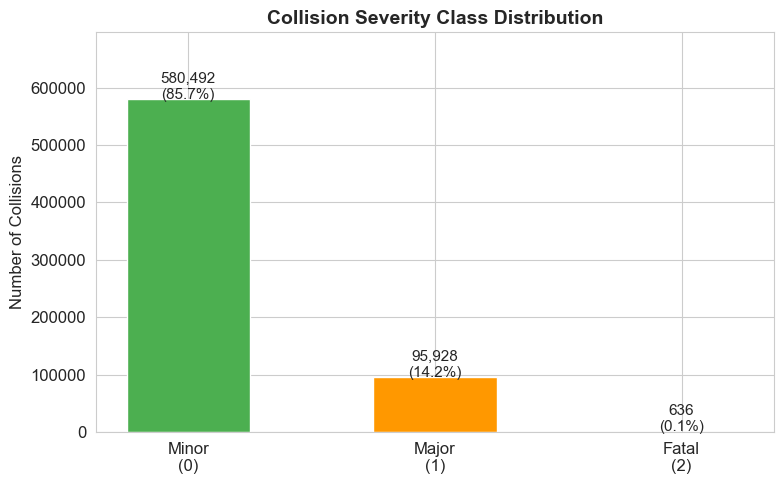

NOTE: Class imbalance — SMOTE will be applied in modeling notebook


In [3]:
fig, ax = plt.subplots(figsize=(8,5))
counts = df['severity'].value_counts().sort_index()
bars = ax.bar(
    [f"{severity_labels[i]}\n({i})" for i in counts.index],
    counts.values,
    color=['#4CAF50','#FF9800','#F44336'], edgecolor='white', width=0.5
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Collision Severity Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Collisions')
ax.set_ylim(0, counts.max()*1.2)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_01_severity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('NOTE: Class imbalance — SMOTE will be applied in modeling notebook')

---
## Plot 2 — Collisions by Hour of Day

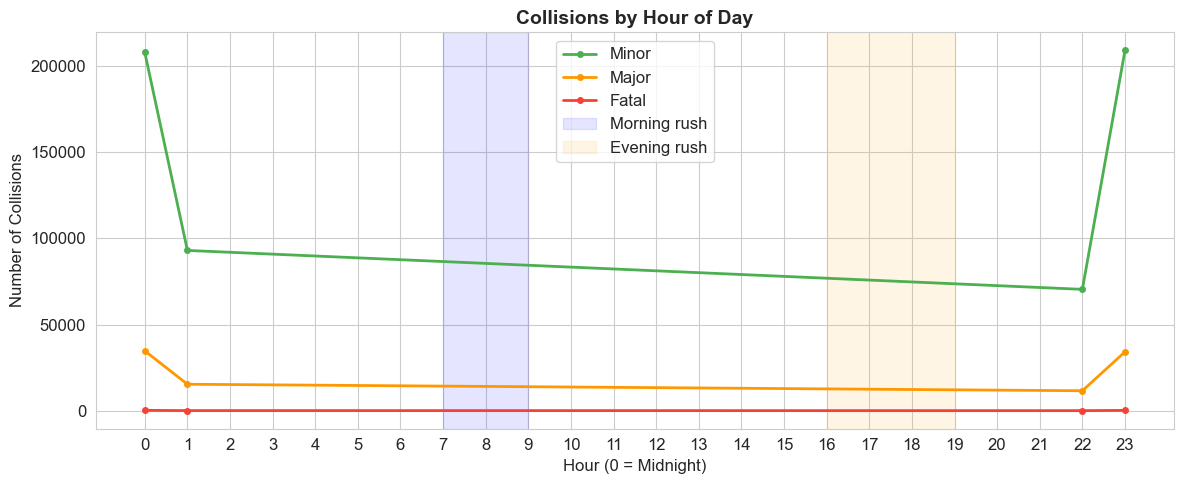

In [4]:
fig, ax = plt.subplots(figsize=(12,5))
hourly = df.groupby(['OCC_HOUR','severity']).size().unstack(fill_value=0)
for i, col in enumerate(hourly.columns):
    ax.plot(hourly.index, hourly[col], marker='o', markersize=4,
            label=severity_labels[col],
            color=['#4CAF50','#FF9800','#F44336'][i], linewidth=2)
ax.axvspan(7,9,   alpha=0.1, color='blue',   label='Morning rush')
ax.axvspan(16,19, alpha=0.1, color='orange', label='Evening rush')
ax.set_title('Collisions by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (0 = Midnight)')
ax.set_ylabel('Number of Collisions')
ax.set_xticks(range(0,24))
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_02_hourly_collisions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Plot 3 — Collisions by Month

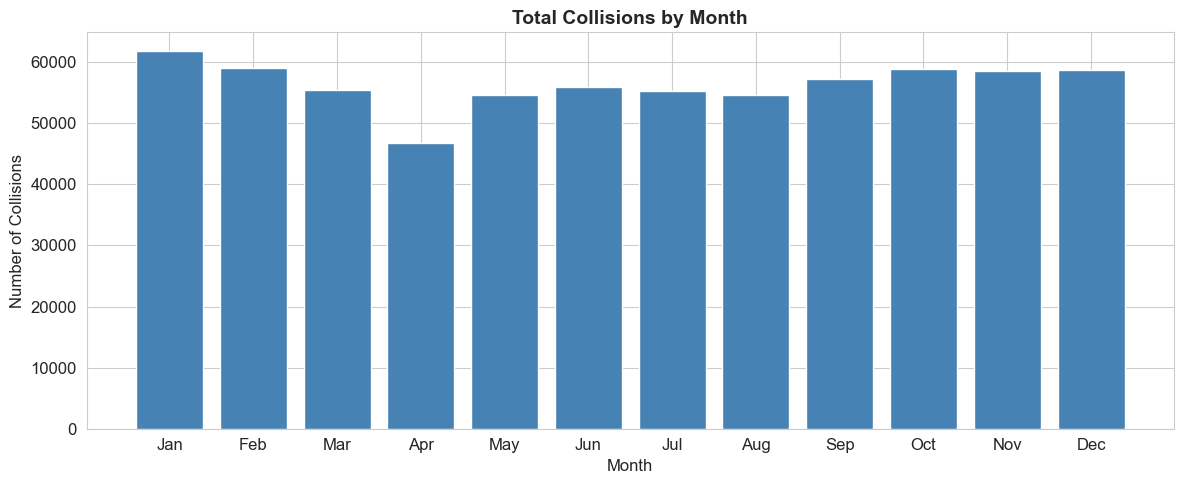

In [5]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('OCC_MONTH').size().reindex(range(1,13), fill_value=0)

fig, ax = plt.subplots(figsize=(12,5))
ax.bar(month_names, monthly.values, color='steelblue', edgecolor='white')
ax.set_title('Total Collisions by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Collisions')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_03_monthly_collisions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Plot 4 — Collisions by Day of Week

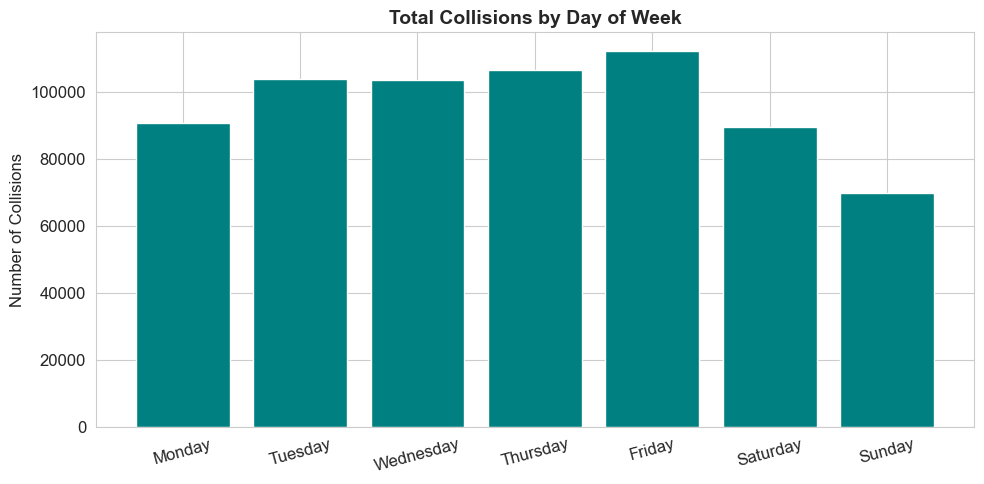

In [6]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_cols  = [c for c in df.columns if c.startswith('OCC_DOW_')]
dow_counts = pd.Series(
    {d.replace('OCC_DOW_',''):df[d].sum() for d in dow_cols}
).reindex(dow_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(dow_order, dow_counts.values, color='teal', edgecolor='white')
ax.set_title('Total Collisions by Day of Week', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Collisions')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_04_dow_collisions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Plot 5 — Weather Condition vs Severity

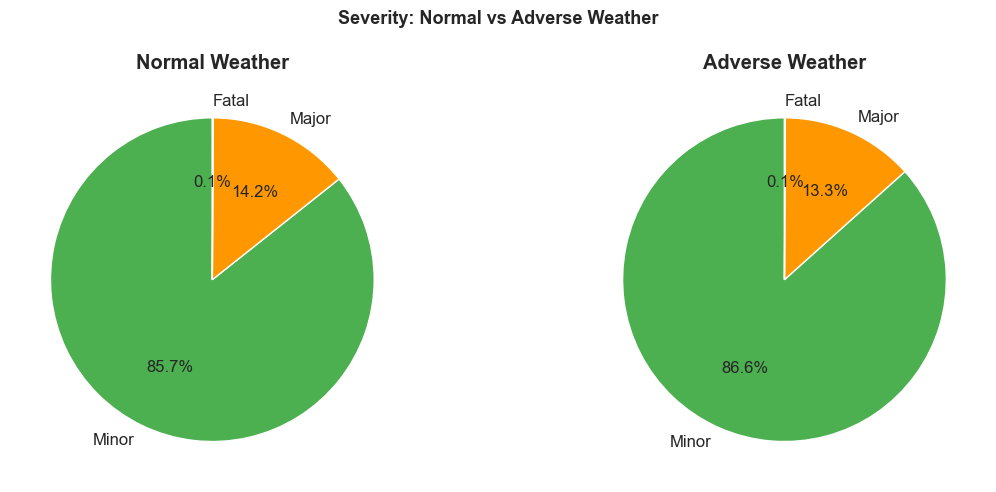

In [7]:
if 'adverse_weather_w' in df.columns:
    fig, axes = plt.subplots(1,2, figsize=(12,5))
    for i, (label, subset) in enumerate(df.groupby('adverse_weather_w')):
        c = subset['severity'].value_counts().sort_index()
        axes[i].pie(c.values,
                    labels=[severity_labels[k] for k in c.index],
                    colors=['#4CAF50','#FF9800','#F44336'],
                    autopct='%1.1f%%', startangle=90)
        axes[i].set_title('Adverse Weather' if label==1 else 'Normal Weather',
                           fontweight='bold')
    plt.suptitle('Severity: Normal vs Adverse Weather', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_FOLDER}plot_05_weather_severity.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Plot 6 — Correlation Heatmap

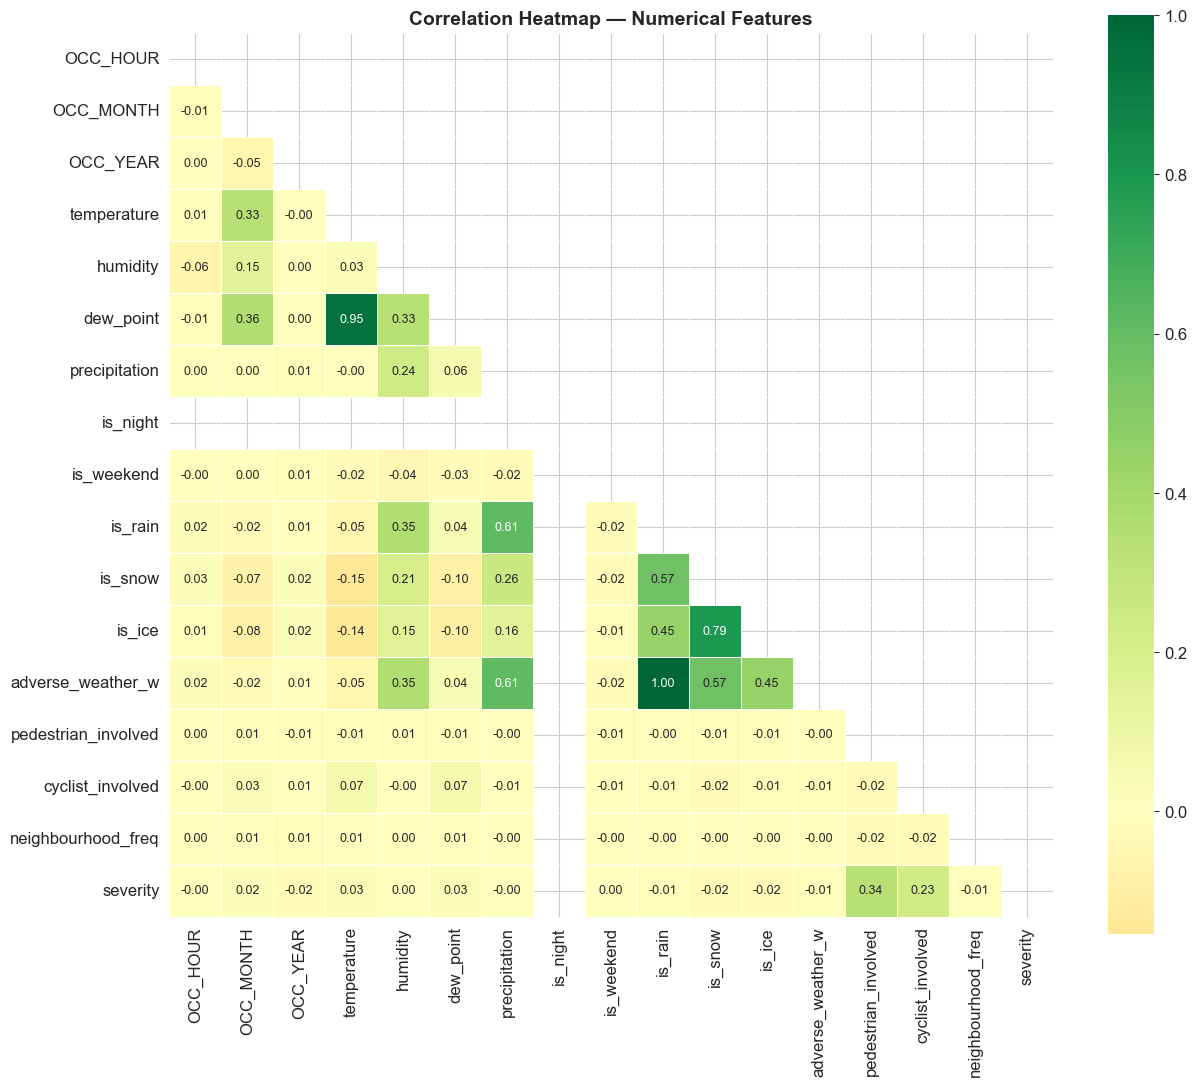

In [8]:
# Plot 6 — Correlation Heatmap
# Only use columns that actually exist in the cleaned dataset
num_cols = ['OCC_HOUR', 'OCC_MONTH', 'OCC_YEAR',
            'temperature', 'humidity', 'dew_point', 'precipitation',
            'is_night', 'is_weekend',
            'is_rain', 'is_snow', 'is_ice', 'adverse_weather_w',
            'pedestrian_involved', 'cyclist_involved',
            'neighbourhood_freq', 'severity']
existing = [c for c in num_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(13, 11))
corr = df[existing].corr()
sns.heatmap(corr,
            mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, linewidths=0.5, square=True, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap — Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_FOLDER}plot_06_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Plot 7 — Top 15 Neighbourhoods by Fatal Collisions

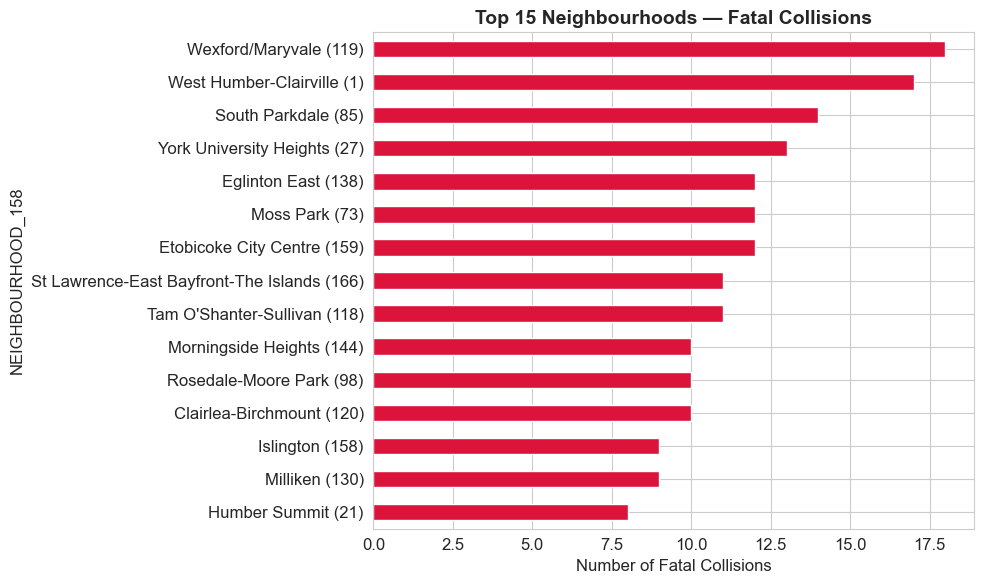

In [9]:
if 'NEIGHBOURHOOD_158' in df.columns:
    fatal_hood = (
        df[df['severity']==2]
        .groupby('NEIGHBOURHOOD_158').size()
        .sort_values(ascending=False).head(15)
    )
    fig, ax = plt.subplots(figsize=(10,6))
    fatal_hood.plot(kind='barh', color='crimson', ax=ax)
    ax.set_title('Top 15 Neighbourhoods — Fatal Collisions', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Fatal Collisions')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{PLOTS_FOLDER}plot_07_neighbourhood_fatal.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Plot 8 — Temperature Distribution by Severity

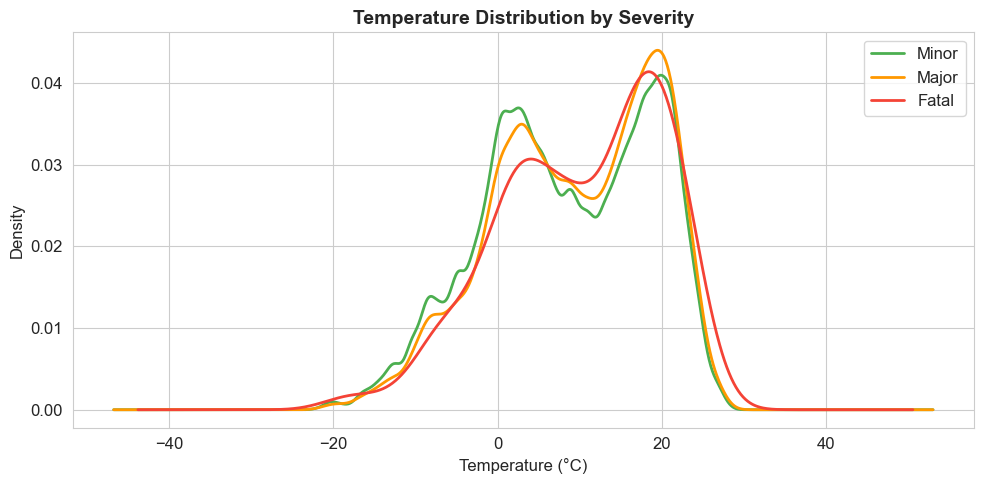

In [10]:
if 'temperature' in df.columns:
    fig, ax = plt.subplots(figsize=(10,5))
    for sev, color in zip([0,1,2], ['#4CAF50','#FF9800','#F44336']):
        df[df['severity']==sev]['temperature'].dropna().plot(
            kind='kde', ax=ax, color=color,
            label=severity_labels[sev], linewidth=2)
    ax.set_title('Temperature Distribution by Severity', fontsize=14, fontweight='bold')
    ax.set_xlabel('Temperature (\u00b0C)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{PLOTS_FOLDER}plot_08_temperature_severity.png', dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
print('All 8 plots saved to:', PLOTS_FOLDER)
print('\n✅ Notebook 3 complete! Open Notebook 4 next.')

All 8 plots saved to: ../MRP - Final Sem/Plots/

✅ Notebook 3 complete! Open Notebook 4 next.
